In [8]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

**Please write your name below** (in case the file names get mixed up)

Adel Sahuc

Gentle reminder: **copy-pasting code from ChatGPT/Claude/Whatever.ai is not allowed.**

In this lab specifically, we will generate random data (with some random noise), so that we know the "ground truth" function that represents the distribution. We will thus be able to see how well we can manage to approximate this function. In future labs, we will use "real" data for which we do not the ground truth distribution, similarly to lab 1.

# Linear regression

We will implement two ways to do linear regression.

In ***this part of this lab only***, since we are interested in recovering a ground truth function, we will not bother splitting the dataset into train/validatation/test sets. In general, *we obviously don't know the ground truth function*. So one of the only ways to ensure that we are not overfitting will be to split the dataset. This is what we will do in other sections and future labs.

## Data generation

Let's generate some fake data (area and age) for houses, and try to predict their price.

Let's start by generating $N$ 2-dimensional training samples, and concatenate them in a matrix $\mathbf{X}_{train}$ of size (N,2)

In [9]:
# Data generation
np.random.seed(42) # we use a random seed so that our random generation is reproducible
N = 50 # number of samples to generate

house_area = np.random.uniform(50,300,size=N) # generate N samples uniformly distributed from 50 to 300
house_age = np.random.uniform(0,150,size=N) # similar

X_train = np.concatenate([
    house_area.reshape(-1,1),
    house_age.reshape(-1,1)
], axis=1) # concatenate the featurs into one input matrix
print(f"Shape of the feature matrix: {X_train.shape}")

Shape of the feature matrix: (50, 2)


Now let's generate the labels $\mathbf{y}_{train}$. We will generate labels that are linear with respect to the input data, with some added random noise that can for instance represent naturally occuring randomness or measurements errors.

In [10]:
# Label generation
noise = np.random.normal(0,5,size=N) # generate some normally distribution random noise
house_price = 1.1 * house_area - 0.5 * house_age + noise # the target is a linear combination of inputs + noise

y_train = house_price
print(f"Shape of the labels vector: {y_train.shape}")

Shape of the labels vector: (50,)


Let's quickly visualize the relation between the target and each individual variable.

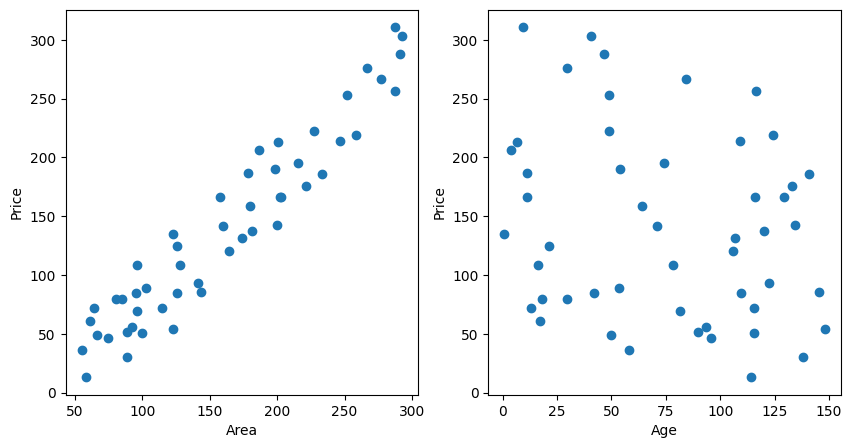

In [11]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 5)) # create 2 plots size by size

# First scatter plot
ax1.scatter(house_area, house_price)
ax1.set_xlabel('Area')
ax1.set_ylabel('Price')

# Second scatter plot
ax2.scatter(house_age, house_price)
ax2.set_xlabel('Age')
ax2.set_ylabel('Price')
plt.show()

We can also display the ground truth lines:

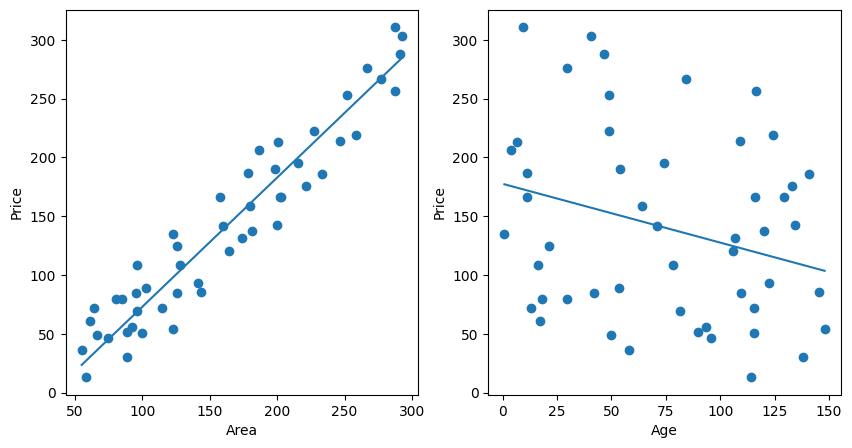

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 5)) # create 2 plots size by size

# First scatter plot
ax1.scatter(house_area, house_price)
ax1.set_xlabel('Area')
ax1.set_ylabel('Price')
x_range_area = np.array([house_area.min(), house_area.max()]) # leftmost and rightmost points on the x axis
y_preds_area = 1.1 * x_range_area - 0.5 * house_age.mean() # corresponding points on the y_axis
ax1.plot(x_range_area, y_preds_area)


# Second scatter plot
ax2.scatter(house_age, house_price)
ax2.set_xlabel('Age')
ax2.set_ylabel('Price')
x_range_age = np.array([house_age.min(), house_age.max()]) # leftmost and rightmost points on the x axis
y_preds_age = 1.1 * house_area.mean() - 0.5 * x_range_age # corresponding points on the y_axis
ax2.plot(x_range_age, y_preds_age)
plt.show()

Notice that to draw the ground truth line for each variable, we also had to take into account the mean impact of the other variable.

## Linear regression implementation: gradient descent

**Are the generated data and ground truth function realistic?**

I think that they are incredibly simple but yes they are realistic enough for this demo. I think more than anything in reality the functions would be a lot more non-linear than here, but for a demo this is great.

Now let's do linear regression! We will assume there is no intercept, i.e. $f(\mathbf{x}) = \mathbf{w}^\top\mathbf{x}$ (there is no additional $w_0$ term)

Given the parameters $\mathbf{w} = (w_1,w_2)^\top$ and the training data $\mathbf{X}$,
predictions can be made with $\hat{\mathbf{y}} = \mathbf{Xw}$

In [13]:
# For example, with an arbitrary vector w:
w_init = np.array([1,2]) # assign random values to w

y_est = X_train @ w_init # compute predictions
print(f"Shape of our predictions: {y_est.shape}")

Shape of our predictions: (50,)


**Implement a function that returns the Mean Square Error (MSE):**
$$J(\mathbf{w}) = \frac{1}{N}  \lVert \mathbf{y} - \mathbf{Xw} \rVert_2^2$$
**given the training data $\mathbf{X}$, labels $\mathbf{y}$ and model parameters $\mathbf{w}$**

In [14]:
def mse(X, w, y):
    y_pred = X @ w
    error = y - y_pred
    mse = np.mean(error ** 2) # the mean of the error ^2 
    return mse

mse(X_train, w_init, house_price) 

np.float64(41623.057563884446)

**How can we estimate the gradient $\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}}$?** (no code required either, just a formula)

$\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}} = -\frac{2}{N} \mathbf{X}^T (\mathbf{y} - \mathbf{X}\mathbf{w})$

***Bonus question: what if we did not have an analytical solution?*** (no code required either, just an *optional* very brief answer)

If we do not have an analytical solution because doing the direct matrix multiplicaiton is too heavy since matrix multiplication is ~O(n^1.8) (something like this) what we could do instead is do a gradient descent algorithm to iteravly update the wheights by lookingat the gradient and aiming to update the wheights such that they minimize loss.

**Implement gradient descent:
$\mathbf{w}_{(t)} = \mathbf{w}_{(t-1)} - \alpha \frac{\partial J(\mathbf{w})}{\partial \mathbf{w}}$**

**and determine suitable values for the parameters $\mathbf{w}$ using gradient descent on the training samples.**

It may be useful to print the training error at each step. If the loss/error is not decreasing, try a smaller value of the learning rate $\alpha$.

In [35]:
num_steps = 10
def grad_descent(w_current, alpha, y_train, X_train, num_steps):
    N = X_train.shape[0]
    for step in range(num_steps):
        # w_next = w_current - alpha * 2/N*(X_train.T)@(y-X_train@w)
        # w_current = w_next
        # print(mse(X_train, w_current, y_train)
        grad = -2/N*(X_train.T)@(y_train-X_train@w_current) # if grad is not negative do grad ascent
        w_current = w_current - alpha*grad
        print(f"MSE at step {step}: {mse(X_train, w_current, y_train)}")
    return w_current

print(f"final weights {grad_descent(w_init, 0.00001, house_price, X_train, 100)}")

MSE at step 0: 13999.429905076246
MSE at step 1: 10911.363470472046
MSE at step 2: 9750.640716988966
MSE at step 3: 8821.587223375942
MSE at step 4: 7989.406996701785
MSE at step 5: 7236.525324276428
MSE at step 6: 6554.822228369794
MSE at step 7: 5937.526296851345
MSE at step 8: 5378.549215065911
MSE at step 9: 4872.381092821768
MSE at step 10: 4414.032824010722
MSE at step 11: 3998.9866625687596
MSE at step 12: 3623.1516744294627
MSE at step 13: 3282.8234135393145
MSE at step 14: 2974.647408601242
MSE at step 15: 2695.586099466353
MSE at step 16: 2442.888897191544
MSE at step 17: 2214.065072651074
MSE at step 18: 2006.8592064761642
MSE at step 19: 1819.2289583430588
MSE at step 20: 1649.3249364908365
MSE at step 21: 1495.4724690513547
MSE at step 22: 1356.1550975190614
MSE at step 23: 1229.9996296628074
MSE at step 24: 1115.7626045525449
MSE at step 25: 1012.3180362924312
MSE at step 26: 918.6463156555125
MSE at step 27: 833.8241602280991
MSE at step 28: 757.015514006685
MSE at step 

**Are your estimated values of the parameters consistent with the ground_truth?**

I got the final weights of '[1.0845, -0.47169]' .... considering that hte equation we are modeling used `house_price = 1.1 * house_area - 0.5 * house_age + noise # the target is a linear combination of inputs + noise` yes its very close and consistent wit hthe ground truth.

## Linear regression implementation: analytical solution and comparison

**Now use the closed-form solution to obtain good values for the parameters $\mathbf{w}$ using the training set.**

In [47]:
# closed form is w = (X^tX)^{-1}X^Ty

import numpy as np
from numpy.linalg import inv
y = house_price
w = inv(X_train.T @ X_train) @ X_train.T @ y


**Display the exact values of the parameters $\mathbf{w}$.
Are they the same as the one you obtained from gradient descent?
Are they the same as the ground truth values? Why?**

In [50]:
print(w)
print(mse(X_train, w, house_price))
"""
Yes they are incredibly similiar ot the ones obtained form gradient descent with a margin of error of 0.01+/- on the weights and an mse that is 0.65 ponts better. 
They are not the same as the ground truth values because of the noise we added to them.
"""

[ 1.0909023  -0.48668339]
20.812686667335427


'\nYes they are incredibly similiar ot the ones obtained form gradient descent with a margin of error of 0.01+/- on the weights and an mse that is 0.65 ponts better. \nThey are not the same as the ground truth values because of the noise we added to them.\n'

In practice, a machine learning engineer does not waste time implementing standard algorithms.
Scikit-learn provides an implementation of a linear regression, among many other learning algorithms.

(Obviously, YOU are not wasting time, because you are learning. Implementing a linear regression is something *everyone* should do at least once in their life).

**Look at the documentation from scikit-learn, and train a linear regression on our data using the provided implementation.
Look at the coefficients $\mathbf{w}$. Are they similar to the ones you found?**

In [52]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)

model.fit(X_train, y_train)

sklearn = model.coef_

print("scikit--learn weights:", sklearn)
print("these are very very similiar to the clsoed form")

scikit-learn weights (w): [ 1.0909023  -0.48668339]


# Over- and under-fitting polynomials

## Data generation

Let's define a new "ground-truth" function $f(x) = \frac{\text{sin}(x)}{x}$, and plot it on $[1,10]$

In [53]:
def f(x: float) -> float:
    """
    Take an float (or an array of floats as input)
    and apply the corresponding function
    """
    return np.sin(x) / x

Let's randomly sample $N$ points $\mathbf{X}_{}$ in range $[1,10]$, and create corresponding labels $\mathbf{y}_{}$ by applying this function and adding some random noise.

(Note: here, since we have a single input feature ($D=1$), $\mathbf{X}_{}$ is actually an $N$-dimensional vector and not an $(N \times D)$ matrix. We could therefore write $\mathbf{x}_{}$ (lowercase) instead. But since we may consider that a vector is an $(N \times 1)$ matrix, we will keep writing $\mathbf{X}_{}$ for the sake of consistency.)

In [54]:
# Data generation
np.random.seed(42) # we use a random seed so that our random generation is reproducible
N = 20 # number of samples to generate

X_full = np.random.uniform(1,10,size=N)
noise = np.random.randn(N)
y_full = f(X_full) + 0.1 * noise

Finally, let's display the sampled points and the ground truth function.

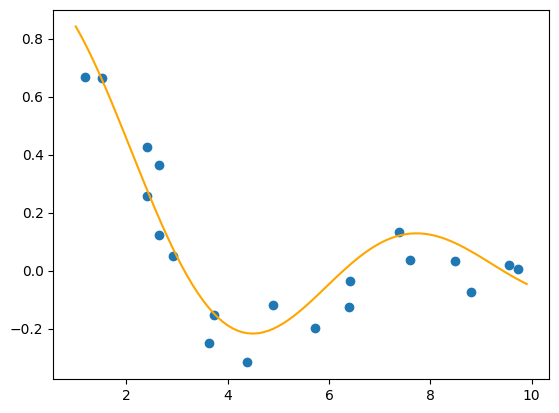

In [55]:
x_range = np.arange(1,10,0.1) # sample points along the x-axis
y_ground_truth = f(x_range) # compute corresponding points on the y-axis
plt.plot(x_range, y_ground_truth, color='orange') # plot the corresponding line
plt.scatter(X_full, y_full) # plot the sampled points
plt.show()

Notice that we do not have many training samples, as may be the case for some real use cases.

We will now assume *we do not know* the ground truth function. We will instead use the sampled points as training and testing examples to try to predict the corresponding labels, try to fit a polynomial curve and evaluate the results.

Let's start by splitting our data into a training a testing set:

In [56]:
# Training set
X_train = X_full[:12] # 12 first elements of X_full
y_train = y_full[:12] # 12 first labels of y_full
# Testing set
X_test = X_full[12:] # remaining elements of X_full
y_test = y_full[12:] # remaining elements of y_full

## Fitting polynomials

**Does it look like fitting a simple linear regression would provide good predictions?**

No it woudln't vecause the data is too cmoplex for simple linear regression.

**Complete the following function that create polynomial features**

In [71]:
def get_polynomial_features(X: np.ndarray, degree=3) -> np.ndarray:
    """
    Return a (Vandermonde) matrix of polynomial features:
    if n-th element of input x is scalar xn,
    then n-th output row is (1, xn, xn^2, xn^3, ..., xn^degree)

    Args:
        - X: vector of 1D features, shape (N,)
        (or equivalently matrix of size (N,1): N rows with 1-dimension features)
        - degree: int, the maximum degree of the polynomial

    Returns:
        polynomial_features: matrix of shape (N, degree+1)
    """
    #TODO: complete the function
    # return np.array(return poly_list ; for col in x.columns for deg in degrees poly_list * x.col])
    # X_flattened = np.ravle(X)
    return np.array([X ** d for d in range(degree +1)]).T
    
print(X_train)
print(X_train.shape)
# print(X_train**2)
poly_features = get_polynomial_features(X_train)
print(poly_features)
print(poly_features.shape)
poly_features = poly_features.T
print(poly_features.shape)

[4.37086107 9.55642876 7.58794548 6.38792636 2.40416776 2.40395068
 1.52275251 8.79558531 6.41003511 7.3726532  1.18526045 9.72918867]
(12,)
[[  1.           4.37086107  19.10442649  83.502794  ]
 [  1.           9.55642876  91.3253306  872.74401566]
 [  1.           7.58794548  57.57691655 436.89050349]
 [  1.           6.38792636  40.80560315 260.66318792]
 [  1.           2.40416776   5.78002264  13.8961441 ]
 [  1.           2.40395068   5.77897889  13.89238024]
 [  1.           1.52275251   2.31877521   3.53092076]
 [  1.           8.79558531  77.36232098 680.44689411]
 [  1.           6.41003511  41.08855006 263.3790483 ]
 [  1.           7.3726532   54.35601521 400.74804949]
 [  1.           1.18526045   1.40484233   1.66510405]
 [  1.           9.72918867  94.65711217 920.93690317]]
(12, 4)
(4, 12)


In [67]:
# Testing
X_for_test = np.array([1,2])
get_polynomial_features(X_for_test) # you should get a result similar to the one below

array([[1, 1],
       [1, 2],
       [1, 4],
       [1, 8]])

**Fit a polynomial of degree 3 to the training data. Plot the corresponding curve along with the training samples.**

To achieve this, you may use either the Scikit-learn implementation of linear regression, your own implementation, or any other method that you deem relevant.

(Optionnaly, go directly to next question, which also includes this question.)

/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_14832/1162066561.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


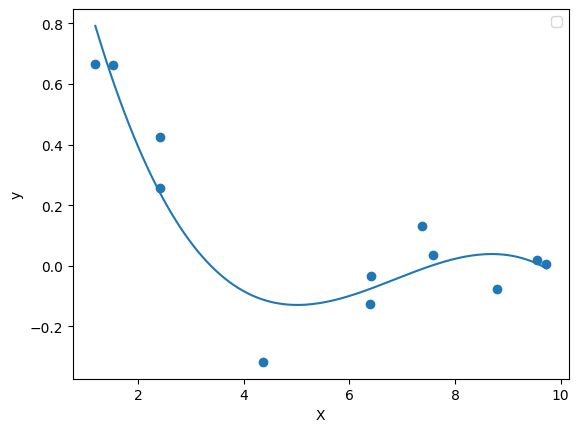

In [76]:
import matplotlib.pyplot as pltf
# from sklearn.linear_model import LinearRegression

X_train_poly = get_polynomial_features(X_train, degree=3)

model = LinearRegression(fit_intercept=False) # I assume false here as haven't done work on w_0 yet meaning for the y axis

model.fit(X_train_poly, y_train)

x_curve = np.linspace(X_train.min(), X_train.max(), 200)
x_curve_poly = get_polynomial_features(x_curve, degree=3)
y_curve_preds = model.predict(x_curve_poly)

print(mse()

plt.scatter(X_train, y_train)
plt.plot(x_curve, y_curve_preds)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


**Do the same for degrees 1 to 10. Which degree seems to yield the lowest training error?**

/Volumes/CrucialX6/Home/dev-env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Volumes/CrucialX6/Home/dev-env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Volumes/CrucialX6/Home/dev-env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_14832/881553249.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


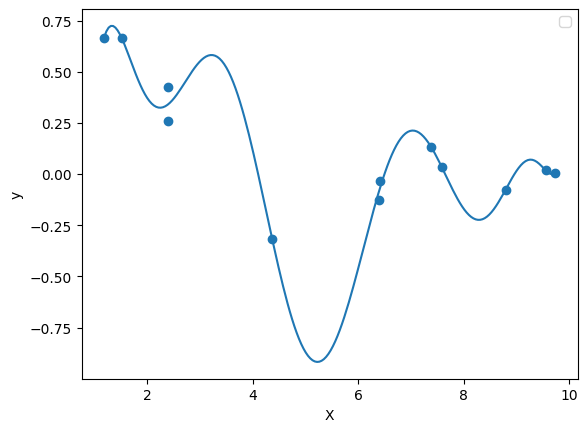

'\nFor training degree 10 seems to havea lot less error ince hte parameters had a lot more flexibility and could hcangehte chape to perfectly or almost perfectly go through each data point.\n'

In [81]:
import matplotlib.pyplot as pltf
# from sklearn.linear_model import LinearRegression

X_train_poly_10 = get_polynomial_features(X_train, degree=10)


# I assume false here as haven't done work on w_0 yet meaning for the y axis
model_10 = LinearRegression(fit_intercept=False)
model_10.fit(X_train_poly_10, y_train)


x_curve_10 = np.linspace(X_train.min(), X_train.max(), 200)
x_curve_poly_10 = get_polynomial_features(x_curve_10, degree=10)
y_curve_preds_10 = model_10.predict(x_curve_poly_10)


plt.scatter(X_train, y_train)
plt.plot(x_curve_10, y_curve_preds_10)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

"""
For training degree 10 seems to havea lot less error ince hte parameters had a lot more flexibility and could hcangehte chape to perfectly or almost perfectly go through each data point.
"""

## Measuring error

**What is the training error for each of the polynomial degree we fitted? What about the test error?**

You may plot the train and test error with respect to the degree of the polynomials

In [85]:
X_train_poly_3 = get_polynomial_features(X_train, degree=3)
X_test_poly_3 = get_polynomial_features(X_test, degree=3)

model_3 = LinearRegression(fit_intercept=False)
model_3.fit(X_train_poly_3, y_train)

y_train_pred_3 = model_3.predict(X_train_poly_3)
y_test_pred_3 = model_3.predict(X_test_poly_3)

train_mse_3 = np.mean((y_train - y_train_pred_3) ** 2)
test_mse_3 = np.mean((y_test - y_test_pred_3) ** 2)

print(f"Degree 3 has train MSE of {train_mse_3} | and test MSE of {test_mse_3}")

X_train_poly_10 = get_polynomial_features(X_train, degree=10)
X_test_poly_10 = get_polynomial_features(X_test, degree=10)

model_10 = LinearRegression(fit_intercept=False)
model_10.fit(X_train_poly_10, y_train)

y_train_pred_10 = model_10.predict(X_train_poly_10)
y_test_pred_10 = model_10.predict(X_test_poly_10)

train_mse_10 = np.mean((y_train - y_train_pred_10) ** 2)
test_mse_10 = np.mean((y_test - y_test_pred_10) ** 2)

print(f"Degree 10 has train MSE of {train_mse_10} | and test MSE of {test_mse_10}")



Degree 3 has train MSE of 0.011077758883993795 | and test MSE of 0.01304275524164523
Degree 10 has train MSE of 0.0014053830929642993 | and test MSE of 0.23434297398799378


**Interpret this in terms of under- and over-fitting**

Clearly to me the degree 10 has overfit as the train error is tiny and its test error is ~1.8 times the degree 3 showing that it didn't generalize to hte datat but 'memorized' the training data instead.

**Which degree seems to be most appropriate for a practical use case? Why?**

For a practical usecase degree 3 seems more useful because it has a better testing accuracy that isn't far off from its training set.

Final note: here, the degree of the polynomial could typically be considered to be a hyper-parameter of the model. We did not do a proper selection of this hyper-parameter using a validation set, but ideally, we should have done so instead of selecting the best value for the degree direclty on the test set. Otherwise, this could lead to inaccurate estimate of the performance of the model.